## ANN - Análisis

Se responde **P3 — Precios de referencia** con los vecinos de `c_bus_ivf` y la comparación de técnicas de `c` y `d`:

> Para procesos de **objeto parecido** (misma `categoria`, descripción similar — ej. "laptops para oficina" en dos regiones), ¿cuánto varía el monto contratado? Una diferencia grande entre compras casi idénticas es indicio de sobreprecio

### Imports

In [1]:
import os, socket, time, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, Window, functions as F

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})
pd.set_option("display.max_colwidth", 80); pd.set_option("display.width", 200)

### Utilidades

- Constantes

In [2]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
final_dir = proyecto / "data" / "final"
vectores_dir = proyecto / "03_ANN" / "temp" / "a_tfidf" / "vectores"
centroides_dir = proyecto / "03_ANN" / "temp" / "b_ind_ivf" / "centroides"
listas_dir = proyecto / "03_ANN" / "temp" / "b_ind_ivf" / "listas"
vecinos_dir = proyecto / "03_ANN" / "temp" / "c_bus_ivf" / "vecinos"
ann_dir = proyecto / "03_ANN" / "temp"
out_dir = ann_dir / "e_analisis"
out_dir.mkdir(parents=True, exist_ok=True)

- Funciones

Parámetros y funciones compartidas de `03_ANN/funciones.ipynb`

In [3]:
ruta_funciones = str(proyecto / "03_ANN" / "funciones.ipynb")
%run $ruta_funciones

- Figuras y tablas

In [4]:
def mostrar_fig(nombre):
    plt.tight_layout()
    plt.savefig(fig_dir / f"{nombre}.png", dpi=150, bbox_inches="tight")
    plt.show()


def guardar_tabla(df, nombre):
    # parquet para el siguiente notebook + json para la página web
    sdf = spark.createDataFrame(df) if isinstance(df, pd.DataFrame) else df
    sdf.coalesce(1).write.mode("overwrite").parquet(str(tab_dir / nombre))
    sdf.toPandas().to_json(web_dir / f"{nombre}.json", orient="records", force_ascii=False, date_format="iso", indent=1)
    return len(df) if isinstance(df, pd.DataFrame) else sdf.count()


def dirs_salida(out_dir):
    fig_dir, tab_dir, web_dir = out_dir / "figs", out_dir / "tablas", out_dir / "web"
    for d in (fig_dir, tab_dir, web_dir):
        d.mkdir(parents=True, exist_ok=True)
    return fig_dir, tab_dir, web_dir


fig_dir, tab_dir, web_dir = dirs_salida(out_dir)

- Spark

In [5]:
spark_master = os.environ.get("spark_master", "local[*]")

builder = (SparkSession.builder
           .appName("ann-analisis")
           .master(spark_master)
           .config("spark.driver.memory",   os.environ.get("SPARK_DRIVER_MEMORY", "4g"))     # 4g (vs 2g en 05): firmas/vectores y joins por pares pesan más que canastas
           .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "4g"))
           .config("spark.sql.shuffle.partitions", "24")                                   # ~231k filas: 24 tareas bastan, las 200 por defecto quedarían casi vacías
           .config("spark.sql.autoBroadcastJoinThreshold", "-1")
           .config("spark.sql.optimizer.canChangeCachedPlanOutputPartitioning", "false")   # bug de joins con caché en Spark 3.5.0                           # sin broadcast automático: los parquets descomprimidos saturaban el driver
           .config("spark.ui.showConsoleProgress", "false")
           .config("spark.sql.session.timeZone", "America/Lima"))

if spark_master.startswith("spark://"):
    builder = (builder.config("spark.driver.host", socket.gethostname())
                      .config("spark.driver.bindAddress", "0.0.0.0"))

spark = builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

### Verificación del cluster

In [ ]:
sc = spark.sparkContext
estado = sc._jsc.sc().getExecutorMemoryStatus()
print(f"Master        : {sc.master}")
print(f"Executors     : {estado.size() - 1}")
print(f"Cores totales : {sc.defaultParallelism}")
print(f"Memoria driver: {sc._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1024**3:.1f} GB")
print("UI del job    : http://localhost:4040")

---
### 1. Carga de vecinos

In [7]:
assert vecinos_dir.exists(), f"No se encuentra {vecinos_dir}; corre c_bus_ivf.ipynb"
vecinos = spark.read.parquet(str(vecinos_dir)).cache()
n_v = vecinos.count(); n_q = vecinos.select("ocid_q").distinct().count()
print(f"Vecinos: {n_v:,} | consultas: {n_q:,} | K = {K} | umbral 'muy parecidos': coseno ≥ {UMBRAL_SIM}")
vecinos.select(F.expr("percentile_approx(cos_sim, array(0.1, 0.5, 0.9))").alias("coseno p10/p50/p90")).show(truncate=False)
muy = vecinos.where(F.col("cos_sim") >= UMBRAL_SIM).cache()
print(f"Pares muy parecidos: {muy.count():,} ({muy.count() / n_v:.1%} de los vecinos)")

Vecinos: 200,614 | consultas: 20,062 | K = 10 | umbral 'muy parecidos': coseno ≥ 0.8


+------------------------+
|coseno p10/p50/p90      |
+------------------------+
|[0.2949, 0.5131, 0.8968]|
+------------------------+



Pares muy parecidos: 32,361 (16.1% de los vecinos)


### 2. Misma entidad vs. distinta entidad

¿La similitud es mayor dentro de una entidad? Se compara el coseno de los vecinos según sean de la misma entidad o de otra

In [8]:
vecinos.groupBy("misma_entidad").agg(F.count("*").alias("vecinos"), F.round(F.avg("cos_sim"), 3).alias("coseno_prom"),
                                      F.round(F.avg((F.col("cos_sim") >= UMBRAL_SIM).cast("int")), 3).alias("frac_muy_parecidos")).show()
vecinos.groupBy("misma_region").agg(F.count("*").alias("vecinos"), F.round(F.avg("cos_sim"), 3).alias("coseno_prom"),
                                     F.round(F.avg((F.col("cos_sim") >= UMBRAL_SIM).cast("int")), 3).alias("frac_muy_parecidos")).show()

+-------------+-------+-----------+------------------+
|misma_entidad|vecinos|coseno_prom|frac_muy_parecidos|
+-------------+-------+-----------+------------------+
|        false| 106809|      0.449|             0.033|
|         true|  93805|      0.672|             0.307|
+-------------+-------+-----------+------------------+

+------------+-------+-----------+------------------+
|misma_region|vecinos|coseno_prom|frac_muy_parecidos|
+------------+-------+-----------+------------------+
|       false|  78949|       0.45|             0.034|
|        true| 121665|      0.621|             0.244|
+------------+-------+-----------+------------------+



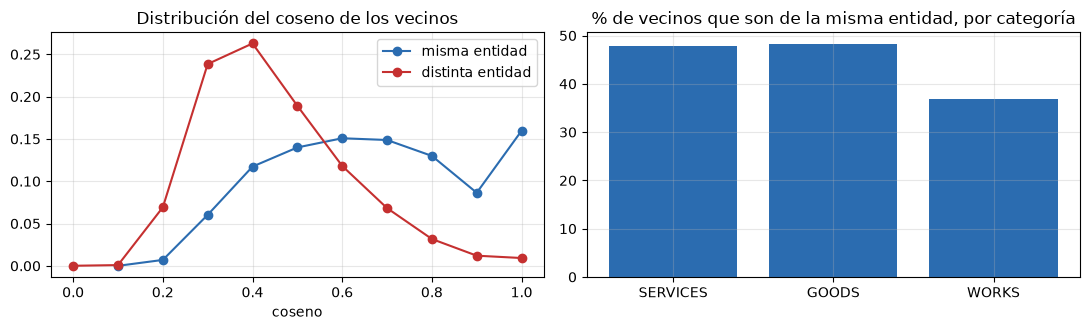

In [9]:
d = vecinos.select("misma_entidad", F.round("cos_sim", 1).alias("c")).groupBy("misma_entidad", "c").count().toPandas()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for ok, col, lab in [(True, "#2b6cb0", "misma entidad"), (False, "#c53030", "distinta entidad")]:
    s = d[d.misma_entidad == ok].sort_values("c"); ax[0].plot(s["c"], s["count"] / s["count"].sum(), marker="o", color=col, label=lab)
ax[0].set_title("Distribución del coseno de los vecinos"); ax[0].set_xlabel("coseno"); ax[0].legend()
cat = vecinos.groupBy("categoria").agg(F.avg(F.col("misma_entidad").cast("int")).alias("frac")).toPandas()
ax[1].bar(cat["categoria"], cat["frac"] * 100, color="#2b6cb0"); ax[1].set_title("% de vecinos que son de la misma entidad, por categoría")
mostrar_fig("misma_entidad")

- Misma entidad: coseno promedio 0.67 y 31% de vecinos muy parecidos; distinta entidad: 0.45 y 3%

- Con regiones pasa lo mismo (0.62 vs 0.45)

- Cada entidad se parece sobre todo a sí misma: sus compras repetidas usan la misma redacción

### 3. Entidades con procesos muy parecidos

Dentro de la misma entidad (compras repetidas) y entre entidades distintas (el mismo objeto comprado por varias)

In [10]:
print("Dentro de la misma entidad:")
(muy.where("misma_entidad").groupBy("entidad_q").agg(F.countDistinct("ocid_q").alias("procesos"), F.count("*").alias("pares"), F.round(F.avg("cos_sim"), 3).alias("coseno"))
    .orderBy(F.desc("pares")).show(10, truncate=45))
print("Entre entidades distintas (pares de entidades):")
(muy.where("NOT misma_entidad").withColumn("e1", F.least("entidad_q", "entidad_v")).withColumn("e2", F.greatest("entidad_q", "entidad_v"))
    .groupBy("e1", "e2").agg(F.count("*").alias("pares"), F.round(F.avg("cos_sim"), 3).alias("coseno")).orderBy(F.desc("pares")).show(10, truncate=40))

Dentro de la misma entidad:


+---------------------------------------------+--------+-----+------+
|                                    entidad_q|procesos|pares|coseno|
+---------------------------------------------+--------+-----+------+
|ORGANISMO DE EVALUACION Y FISCALIZACION AM...|     262| 2483| 0.984|
|       GOBIERNO REGIONAL DE PUNO SEDE CENTRAL|     203| 1065| 0.888|
|   GOBIERNO REGIONAL DE AYACUCHO SEDE CENTRAL|     154|  754| 0.876|
|                      SEGURO SOCIAL DE  SALUD|     242|  508| 0.917|
|                      PETROLEOS DEL PERU S.A.|     135|  423| 0.961|
|                             EJERCITO PERUANO|     133|  338| 0.923|
|PROGRAMA DE DESARROLLO PRODUCTIVO AGRARIO ...|      76|  337| 0.916|
|   GOBIERNO REGIONAL DE AREQUIPA SEDE CENTRAL|      89|  328|  0.88|
|           MUNICIPALIDAD DISTRITAL DE PICHARI|      76|  282| 0.887|
|COMISION DE PROMOCION DEL PERU PARA LA EXP...|      95|  277| 0.887|
+---------------------------------------------+--------+-----+------+
only showing top 10 

+----------------------------------------+----------------------------------------+-----+------+
|                                      e1|                                      e2|pares|coseno|
+----------------------------------------+----------------------------------------+-----+------+
|GOBIERNO REGIONAL DE ICA-HOSPITAL REG...|INSTITUTO NACIONAL DE ENFERMEDADES NE...|   17| 0.928|
| GOBIERNO REGIONAL DE CUSCO SEDE CENTRAL|MUNICIPALIDAD DISTRITAL DE ANDAHUAYLI...|   12| 0.975|
|    MUNICIPALIDAD DISTRITAL DE PICHANAKI| MUNICIPALIDAD PROVINCIAL DE CHANCHAMAYO|   11| 0.848|
|MUNICIPALIDAD PROVINCIAL DE ANGARAES ...|       MUNICIPALIDAD PROVINCIAL DE LAMAS|   10| 0.864|
|GOBIERNO REGIONAL DE AYACUCHO - HOSPI...|GOBIERNO REGIONAL DE ICA-HOSPITAL REG...|   10| 0.861|
|    CORTE SUPERIOR DE JUSTICIA DE ANCASH|                          PODER JUDICIAL|    9| 0.844|
|ORGANISMO SUPERVISOR DE LA INVERSION ...|                 TRIBUNAL CONSTITUCIONAL|    8| 0.993|
|HOSPITAL DE APOYO DEPARTAMENT

- Dentro de la misma entidad lidera OEFA (262 procesos, 2,483 pares, coseno 0.98), el mismo caso de `02_Similitud`; le siguen los GORE de Puno y Ayacucho, EsSalud y Petroperú

- Entre entidades distintas las coincidencias son pocas (máx. 17 pares) y suelen ser instituciones parecidas: hospitales regionales con el INEN, una Corte Superior con el Poder Judicial, municipalidades vecinas

### 4. Regiones

Qué regiones concentran procesos muy parecidos, y entre qué pares de regiones se repite el mismo objeto de compra

+----------------+-----+-----------------+-------------+------------------+
|        region_q|pares|frac_misma_region|vecinos_total|frac_muy_parecidos|
+----------------+-----+-----------------+-------------+------------------+
|            LIMA|10933|            0.961|        58108|             0.188|
|            PUNO| 1460|            0.981|         4676|             0.312|
|        HUAMANGA| 1213|            0.965|         4770|             0.254|
|           CUSCO| 1174|            0.862|         6510|              0.18|
|   LA CONVENCION| 1008|            0.951|         5840|             0.173|
|        AREQUIPA|  959|              0.9|         6450|             0.149|
|  MARISCAL NIETO|  641|            0.972|         3030|             0.212|
|        HUANCAYO|  555|            0.924|         3880|             0.143|
|          CALLAO|  550|            0.871|         4060|             0.135|
|        TRUJILLO|  533|            0.857|         4080|             0.131|
|CORONEL POR

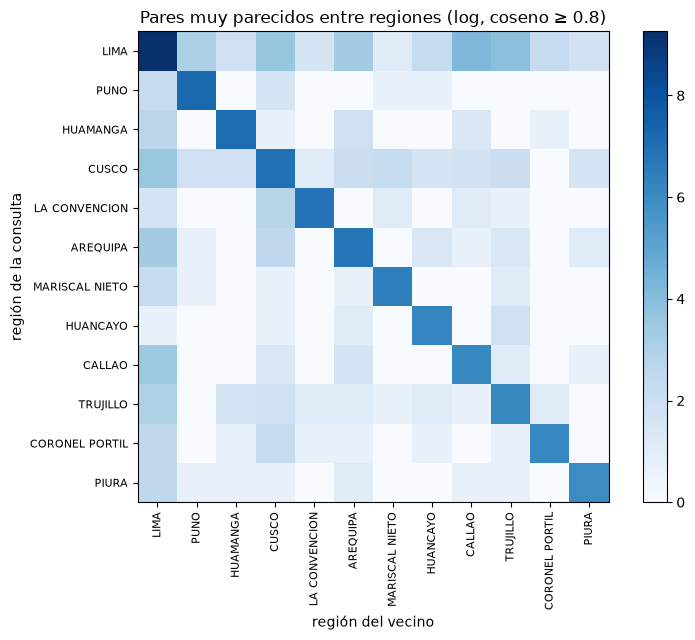

In [11]:
reg = (muy.groupBy("region_q").agg(F.count("*").alias("pares"), F.round(F.avg(F.col("misma_region").cast("int")), 3).alias("frac_misma_region"))
          .join(vecinos.groupBy("region_q").agg(F.count("*").alias("vecinos_total")), "region_q")
          .withColumn("frac_muy_parecidos", F.round(F.col("pares") / F.col("vecinos_total"), 3)).orderBy(F.desc("pares")))
reg.show(12, truncate=30)

# 12 regiones con más pares: la matriz sigue siendo legible
top_reg = [r_["region_q"] for r_ in reg.where("region_q IS NOT NULL").limit(12).collect()]
mat = (muy.where(F.col("region_q").isin(top_reg) & F.col("region_v").isin(top_reg))
          .groupBy("region_q").pivot("region_v", top_reg).count().fillna(0).toPandas().set_index("region_q").reindex(top_reg))
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(np.log1p(mat.values), cmap="Blues")
ax.set_xticks(range(len(top_reg))); ax.set_xticklabels([r_[:14] for r_ in top_reg], rotation=90, fontsize=8)
ax.set_yticks(range(len(top_reg))); ax.set_yticklabels([r_[:14] for r_ in top_reg], fontsize=8)
ax.set_xlabel("región del vecino"); ax.set_ylabel("región de la consulta"); ax.set_title(f"Pares muy parecidos entre regiones (log, coseno ≥ {UMBRAL_SIM})"); ax.grid(False)
plt.colorbar(im, ax=ax, fraction=.04); mostrar_fig("regiones")

- La diagonal es similitud dentro de la misma región; fuera de ella está el mismo objeto comprado en regiones distintas, que es lo que permite comparar precios

- Entre el 86% y el 98% de los pares muy parecidos de cada región son con la misma región: los objetos que se repiten entre regiones son una minoría

### 5. Variación del monto entre procesos muy parecidos (P3)

- Para cada consulta con vecinos muy parecidos y con monto: `ratio = monto_consulta / mediana(monto de sus vecinos)`. En log₂: 0 = paga lo mismo, +1 = el doble, −1 = la mitad

- Es una **señal**, no prueba de sobreprecio: el monto es total (no unitario) y los textos parecidos pueden esconder cantidades o especificaciones distintas

In [12]:
base = muy.where(F.col("monto_final_q").isNotNull() & F.col("monto_final_v").isNotNull() & (F.col("monto_final_q") > 0) & (F.col("monto_final_v") > 0))
var = (base.groupBy("ocid_q", "entidad_q", "region_q", "categoria", "monto_final_q")
           .agg(F.count("*").alias("vecinos"), F.expr("percentile_approx(monto_final_v, 0.5)").alias("monto_mediana_vecinos"),
                F.min("monto_final_v").alias("monto_min_v"), F.max("monto_final_v").alias("monto_max_v"))
           .withColumn("ratio", F.col("monto_final_q") / F.col("monto_mediana_vecinos"))
           .withColumn("log2_ratio", F.log2("ratio")).cache())
n_var = var.count()
print(f"Consultas con vecinos muy parecidos y monto comparable: {n_var:,}")
var.select(F.expr("percentile_approx(log2_ratio, array(0.05, 0.25, 0.5, 0.75, 0.95))").alias("log2(ratio) p5/p25/p50/p75/p95")).show(truncate=False)
# cortes de 2x y 5x: el doble y el quíntuple de lo que pagan los vecinos, fáciles de leer
print(f"Pagan ≥ 2x la mediana de sus vecinos: {var.where('ratio >= 2').count():,} ({var.where('ratio >= 2').count() / n_var:.1%}) | "
      f"≥ 5x: {var.where('ratio >= 5').count():,} ({var.where('ratio >= 5').count() / n_var:.1%})")

Consultas con vecinos muy parecidos y monto comparable: 10,433
+----------------------------------------------------------------------------------------+
|log2(ratio) p5/p25/p50/p75/p95                                                          |
+----------------------------------------------------------------------------------------+
|[-1.4412444270949072, -0.15454529343521006, 0.0, 0.31753632577020446, 1.884658338728678]|
+----------------------------------------------------------------------------------------+



Pagan ≥ 2x la mediana de sus vecinos: 1,262 (12.1%) | ≥ 5x: 343 (3.3%)


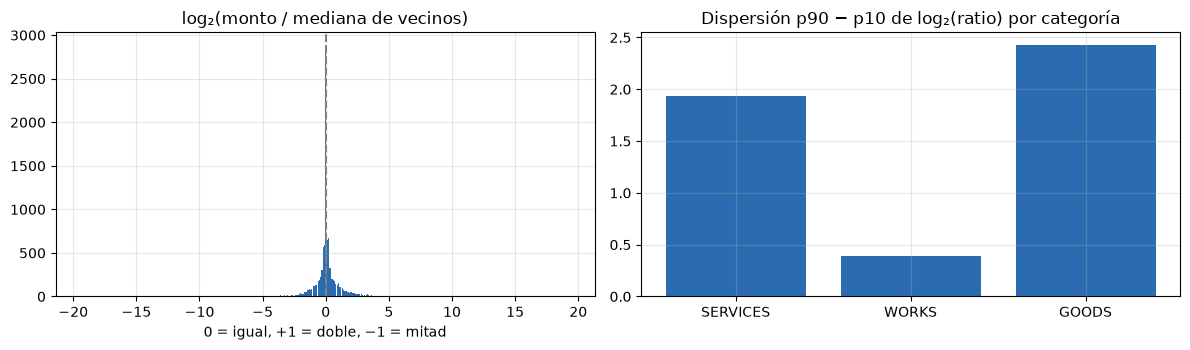

In [13]:
h = var.select(F.round("log2_ratio", 1).alias("l")).groupBy("l").count().orderBy("l").toPandas()
por_cat = var.groupBy("categoria").agg(F.expr("percentile_approx(log2_ratio, 0.5)").alias("p50"), F.expr("percentile_approx(log2_ratio, 0.9)").alias("p90"),
                                       F.expr("percentile_approx(log2_ratio, 0.1)").alias("p10")).toPandas()
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].bar(h["l"], h["count"], width=.09, color="#2b6cb0"); ax[0].axvline(0, color="gray", ls="--"); ax[0].set_title("log₂(monto / mediana de vecinos)"); ax[0].set_xlabel("0 = igual, +1 = doble, −1 = mitad")
x = np.arange(len(por_cat)); ax[1].bar(x, por_cat["p90"] - por_cat["p10"], color="#2b6cb0"); ax[1].set_xticks(x); ax[1].set_xticklabels(por_cat["categoria"])
ax[1].set_title("Dispersión p90 − p10 de log₂(ratio) por categoría"); mostrar_fig("variacion_monto")

- 10,433 consultas con monto comparable; la mediana paga lo mismo que sus vecinos (log₂ = 0)

- La mitad central está entre 0.90x y 1.25x, y los extremos (5%–95%) entre 0.37x y 3.7x

- El 12.1% paga 2 veces o más que la mediana de sus vecinos y el 3.3%, 5 veces o más

### 6. Mismo objeto, otra región

- P3 pone como ejemplo el mismo objeto comprado en dos regiones. Se comparan los pares muy parecidos (coseno ≥ `UMBRAL_SIM`, siempre de la misma categoría) según sean de la misma región o de regiones distintas

- Diferencia de monto del par: `|log₂(monto_consulta / monto_vecino)|`; 1 = uno paga el doble que el otro

In [14]:
pares_m = (base.withColumn("dif_log2", F.abs(F.log2(F.col("monto_final_q") / F.col("monto_final_v"))))
               .withColumn("tipo", F.when(F.col("misma_entidad"), "misma entidad")
                                    .when(F.col("misma_region"), "otra entidad, misma región").otherwise("otra región")))
cruce = (pares_m.groupBy("tipo", "categoria")
                .agg(F.count("*").alias("pares"), F.expr("percentile_approx(dif_log2, array(0.5, 0.9))").alias("p"),
                     F.avg((F.col("dif_log2") >= 1).cast("int")).alias("frac_2x"))
                .select("tipo", "categoria", "pares", F.round(F.pow(F.lit(2), F.col("p")[0]), 2).alias("ratio_mediano"),
                        F.round(F.pow(F.lit(2), F.col("p")[1]), 2).alias("ratio_p90"), F.round(F.col("frac_2x") * 100, 1).alias("pct_2x_o_mas"))
                .orderBy("categoria", "tipo").toPandas())
cruce

,tipo,categoria,pares,ratio_mediano,ratio_p90,pct_2x_o_mas
0,misma entidad,GOODS,10807,1.48,5.21,34.2
1,"otra entidad, misma región",GOODS,345,2.36,8.75,59.1
2,otra región,GOODS,1784,2.10,7.82,53.1
3,misma entidad,SERVICES,12654,1.29,3.75,25.9
4,"otra entidad, misma región",SERVICES,498,2.32,11.46,57.2
5,otra región,SERVICES,556,2.04,6.94,50.5
6,misma entidad,WORKS,2112,1.05,1.61,5.5
7,"otra entidad, misma región",WORKS,8,1.25,2.28,12.5
8,otra región,WORKS,6,1.36,13.05,33.3


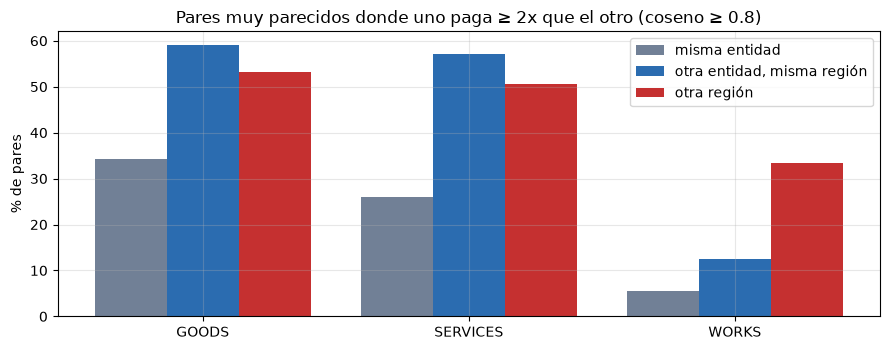

In [15]:
fig, ax = plt.subplots(figsize=(9, 3.6))
tipos = ["misma entidad", "otra entidad, misma región", "otra región"]
cats = sorted(cruce["categoria"].unique()); x = np.arange(len(cats)); w = .27
for k_, (t_, col) in enumerate(zip(tipos, ["#718096", "#2b6cb0", "#c53030"])):
    v = [cruce[(cruce.tipo == t_) & (cruce.categoria == c)]["pct_2x_o_mas"].sum() for c in cats]
    ax.bar(x + (k_ - 1) * w, v, w, color=col, label=t_)
ax.set_xticks(x); ax.set_xticklabels(cats); ax.set_ylabel("% de pares")
ax.set_title(f"Pares muy parecidos donde uno paga ≥ 2x que el otro (coseno ≥ {UMBRAL_SIM})"); ax.legend()
mostrar_fig("otra_region")

- **La región no es lo que separa los montos; la entidad sí.** Entre procesos muy parecidos de la misma entidad, la diferencia mediana es 1.3x–1.5x en bienes y servicios; con otra entidad sube a ~2.0x–2.4x, sea de la misma región o de otra

- Más de la mitad de los pares de bienes y servicios entre entidades distintas tiene uno que paga 2x o más (50–59%), frente a 26–34% dentro de la misma entidad

- Las obras casi no se repiten entre entidades (14 pares) y dentro de la misma entidad varían poco (5.5% con 2x o más)

- Lectura: el mismo texto describe compras de **escala** distinta (cantidades, población atendida), y la escala depende de la entidad, no de la región

### 7. Dónde se paga más: regiones y entidades

Mediana de `log2_ratio` por región y por entidad (≥ `MIN_CONS` consultas). Positivo = esa región/entidad paga por encima de lo que pagan otras por lo mismo

In [16]:
MIN_CONS = 20              # mínimo de consultas por región/entidad para que la mediana no dependa de 2–3 casos
reg_var = (var.groupBy("region_q").agg(F.count("*").alias("consultas"), F.round(F.expr("percentile_approx(log2_ratio, 0.5)"), 3).alias("log2_ratio_mediana"),
                                       F.round(F.avg((F.col("ratio") >= 2).cast("int")), 3).alias("frac_paga_2x"))
              .where(f"consultas >= {MIN_CONS}").orderBy(F.desc("log2_ratio_mediana")))
reg_var.show(12, truncate=30)
ent_var = (var.groupBy("entidad_q").agg(F.count("*").alias("consultas"), F.round(F.expr("percentile_approx(log2_ratio, 0.5)"), 3).alias("log2_ratio_mediana"),
                                        F.round(F.avg((F.col("ratio") >= 2).cast("int")), 3).alias("frac_paga_2x"))
              .where(f"consultas >= {MIN_CONS}").orderBy(F.desc("log2_ratio_mediana")))
ent_var.show(10, truncate=45)

+-----------------+---------+------------------+------------+
|         region_q|consultas|log2_ratio_mediana|frac_paga_2x|
+-----------------+---------+------------------+------------+
|              ILO|       49|             0.178|       0.184|
|         CAYLLOMA|       29|             0.152|       0.207|
|      CHANCHAMAYO|       45|             0.111|       0.111|
|        SAN ROMAN|       54|             0.087|       0.185|
|         CARABAYA|       22|              0.04|       0.182|
|      PAUCARTAMBO|       32|             0.033|       0.125|
|            CUSCO|      336|             0.031|       0.167|
|      CHACHAPOYAS|       54|             0.029|       0.111|
|          ESPINAR|       65|             0.026|       0.185|
|DATEM DEL MARAÑON|       29|             0.012|         0.0|
|        CHURCAMPA|       20|              0.01|         0.0|
| CORONEL PORTILLO|      146|             0.009|       0.123|
+-----------------+---------+------------------+------------+
only sho

+---------------------------------------------+---------+------------------+------------+
|                                    entidad_q|consultas|log2_ratio_mediana|frac_paga_2x|
+---------------------------------------------+---------+------------------+------------+
|EMPRESA REGIONAL DE SERVICIOS PUBLICOS DE ...|       23|             0.238|       0.217|
|INSTITUTO NACIONAL DE ENFERMEDADES NEOPLAS...|       33|              0.21|       0.273|
|          MINISTERIO DE RELACIONES EXTERIORES|       25|             0.202|        0.12|
|         INSTITUTO NACIONAL DE SALUD DEL NIÑO|       20|             0.135|         0.4|
|SUPERINTENDENCIA NACIONAL DE ADUANAS Y DE ...|       54|              0.13|       0.185|
|     MUNICIPALIDAD DISTRITAL DE SAN SEBASTIAN|       27|               0.1|       0.222|
|           MUNICIPALIDAD PROVINCIAL DEL CUSCO|       28|             0.083|        0.25|
|EMPRESA DE SERVICIO PUBLICO DE ELECTRICIDA...|       31|             0.081|       0.129|
|COMISION 

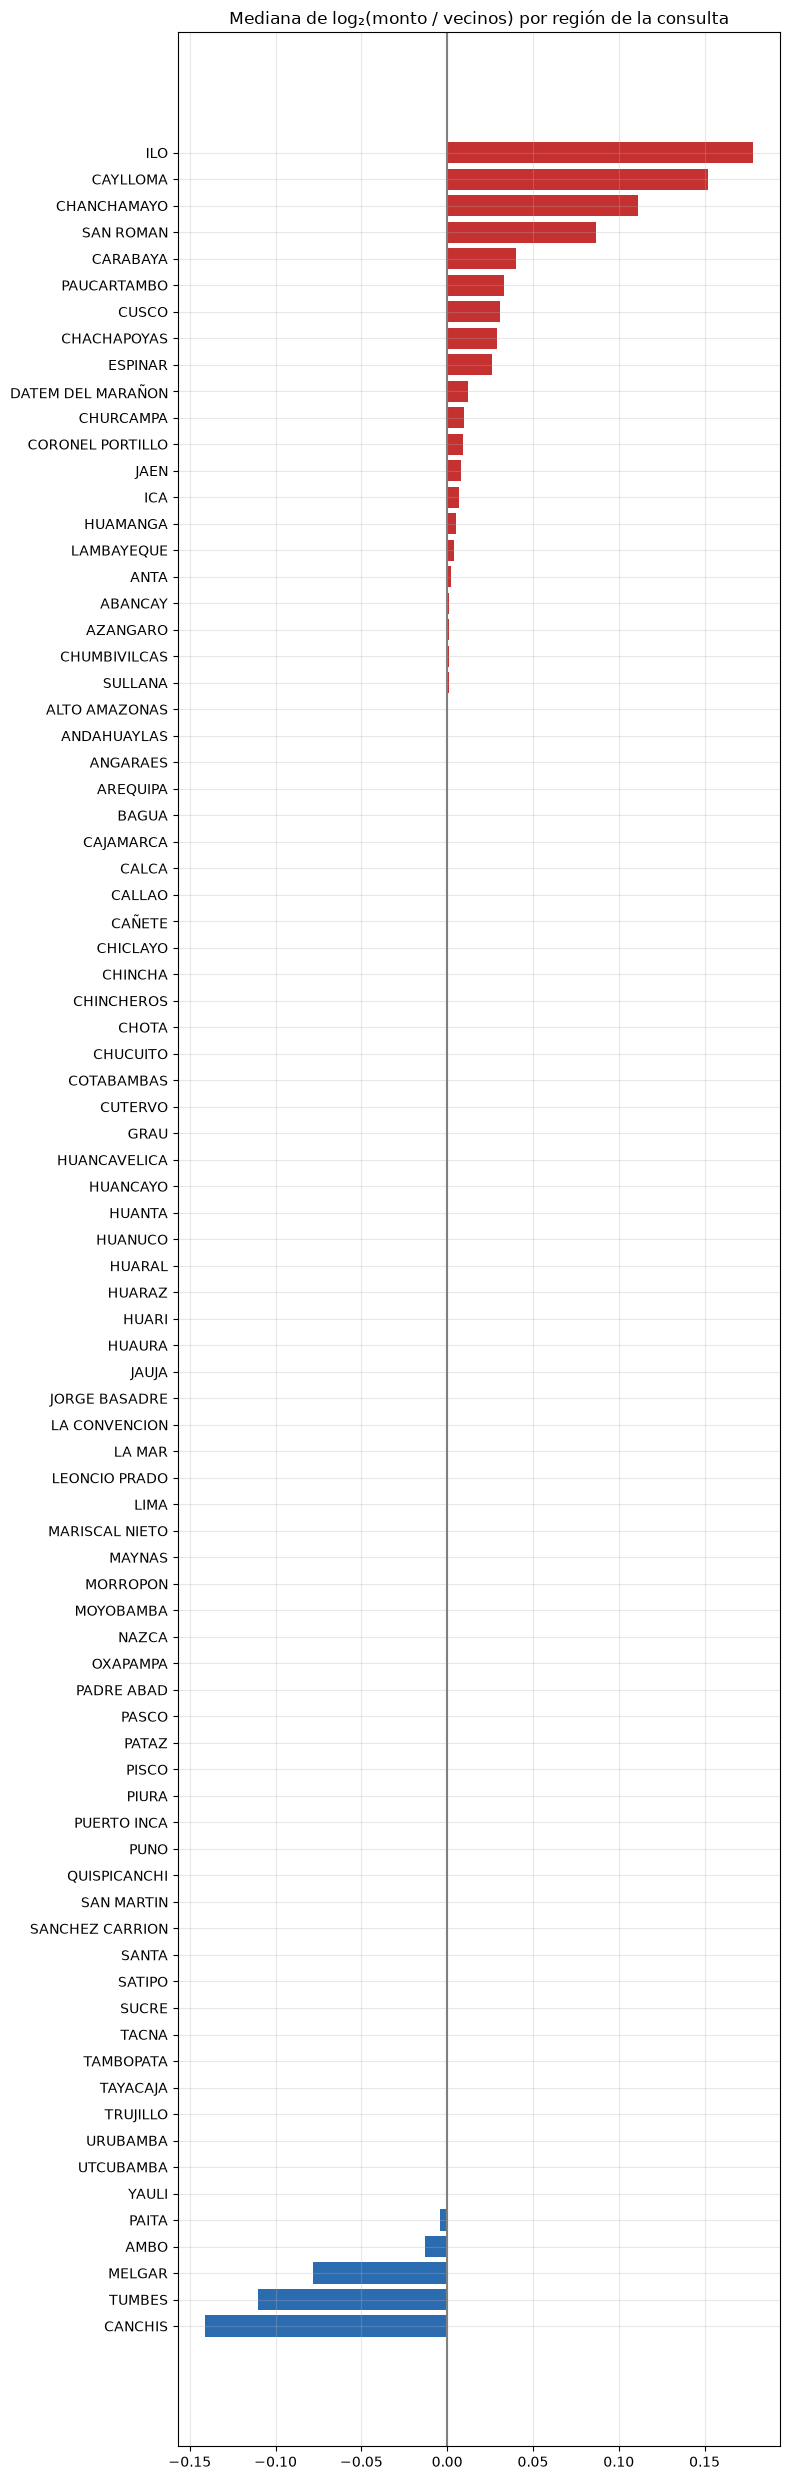

In [17]:
rp = reg_var.toPandas().iloc[::-1]
if len(rp):
    fig, ax = plt.subplots(figsize=(8, max(3, .3 * len(rp))))
    ax.barh(rp["region_q"].str[:25], rp["log2_ratio_mediana"], color=["#c53030" if v > 0 else "#2b6cb0" for v in rp["log2_ratio_mediana"]])
    ax.axvline(0, color="gray"); ax.set_title("Mediana de log₂(monto / vecinos) por región de la consulta"); mostrar_fig("region_mediana")

- Ninguna región paga sistemáticamente más: la mediana más alta es Ilo (log₂ 0.18 ≈ 1.13x)

- Las entidades por encima de sus vecinos también están cerca de 1: la más alta es una empresa regional de servicios públicos (≈ 1.18x), seguida del INEN (≈ 1.16x) y Relaciones Exteriores (≈ 1.15x)

### 8. Ejemplos: mismo objeto, regiones distintas, montos distintos

In [18]:
desc = spark.read.parquet(str(final_dir)).select("ocid", "descripcion")
ej = (base.where("NOT misma_region").withColumn("ratio", F.greatest(F.col("monto_final_q") / F.col("monto_final_v"), F.col("monto_final_v") / F.col("monto_final_q")))
          .orderBy(F.desc("cos_sim"), F.desc("ratio")).where("ratio >= 2").limit(3)
          .join(desc.withColumnRenamed("ocid", "ocid_q").withColumnRenamed("descripcion", "desc_q"), "ocid_q")
          .join(desc.withColumnRenamed("ocid", "ocid_v").withColumnRenamed("descripcion", "desc_v"), "ocid_v").collect())
for r_ in ej:
    print(f"\ncoseno {r_['cos_sim']} | ratio {r_['ratio']:.1f}x")
    print(f"  [{r_['region_q']}] {r_['entidad_q'][:40]} — S/ {r_['monto_final_q']:,.0f}\n    {r_['desc_q'][:160]}")
    print(f"  [{r_['region_v']}] {r_['entidad_v'][:40]} — S/ {r_['monto_final_v']:,.0f}\n    {r_['desc_v'][:160]}")


coseno 1.0 | ratio 56.1x
  [AREQUIPA] EMPRESA DE GENERACION ELECTRICA DE AREQU — S/ 714,000
    SERVICIO DE AGENCIAMIENTO DE PASAJES AÉREOS
  [LIMA] UNIDAD EJECUTORA 002 INICTEL-UNI — S/ 12,738
    SERVICIO DE AGENCIAMIENTO DE PASAJES AÉREOS

coseno 1.0 | ratio 48.1x
  [PAUCARTAMBO] MUNICIPALIDAD DISTRITAL DE HUANCARANI — S/ 62,496
    ADQUISICION DE LECHE ENTERA
  [LIMA] MUNICIPALIDAD DISTRITAL DE PUENTE PIEDRA — S/ 3,008,326
    ADQUISICION DE LECHE EVAPORADA ENTERA

coseno 1.0 | ratio 63.3x
  [CONDESUYOS] MUNICIPALIDAD DISTRITAL DE CAYARANI — S/ 47,520
    ADQUISICION DE LECHE EVAPORADA ENTERA DE 400 GR A MAS
  [LIMA] MUNICIPALIDAD DISTRITAL DE PUENTE PIEDRA — S/ 3,008,326
    ADQUISICION DE LECHE EVAPORADA ENTERA


- Los extremos son el mismo producto en **cantidades** distintas: pasajes aéreos 56x (EGASA vs INICTEL), leche evaporada 48x–63x (Puente Piedra frente a municipios rurales de Cusco y Arequipa)

- El monto es total, no unitario: sin la cantidad no se puede decir quién paga más por unidad

### 9. Experimento: umbral de "muy parecidos" (`UMBRAL_SIM`)

Se repite el análisis de montos con coseno ≥ 0.70, 0.80 y 0.90 para ver cuánto dependen las conclusiones del umbral

In [19]:
EXP_UMBRAL_SIM = [0.70, 0.80, 0.90]   # más laxo, actual y más estricto

def resumen_umbral(u):
    m = vecinos.where(F.col("cos_sim") >= u)
    con_monto = m.where(F.col("monto_final_q").isNotNull() & F.col("monto_final_v").isNotNull() &
                        (F.col("monto_final_q") > 0) & (F.col("monto_final_v") > 0))
    v = (con_monto.groupBy("ocid_q", "monto_final_q").agg(F.expr("percentile_approx(monto_final_v, 0.5)").alias("mediana_v"))
                  .withColumn("ratio", F.col("monto_final_q") / F.col("mediana_v")))
    rp = m.agg(F.count("*").alias("pares"), F.avg(F.col("misma_entidad").cast("int")).alias("misma_entidad"),
               F.avg(F.col("misma_region").cast("int")).alias("misma_region")).first()
    rv = v.agg(F.count("*").alias("consultas"), F.expr("percentile_approx(ratio, array(0.25, 0.75))").alias("p"),
               F.avg((F.col("ratio") >= 2).cast("int")).alias("f2"), F.avg((F.col("ratio") >= 5).cast("int")).alias("f5")).first()
    return {"UMBRAL_SIM": u, "pares": rp["pares"], "frac_vecinos": round(rp["pares"] / n_v, 3),
            "frac_misma_entidad": round(rp["misma_entidad"], 3), "frac_misma_region": round(rp["misma_region"], 3),
            "consultas_con_monto": rv["consultas"], "ratio_p25": round(rv["p"][0], 2), "ratio_p75": round(rv["p"][1], 2),
            "frac_paga_2x": round(rv["f2"], 3), "frac_paga_5x": round(rv["f5"], 3)}

tabla_us = pd.DataFrame([resumen_umbral(u_) for u_ in EXP_UMBRAL_SIM])
tabla_us

,UMBRAL_SIM,pares,frac_vecinos,frac_misma_entidad,frac_misma_region,consultas_con_monto,ratio_p25,ratio_p75,frac_paga_2x,frac_paga_5x
0,0.7,50929,0.254,0.827,0.869,12619,0.84,1.36,0.154,0.045
1,0.8,32361,0.161,0.890,0.918,10433,0.90,1.25,0.121,0.033
2,0.9,19810,0.099,0.926,0.942,8099,0.92,1.14,0.082,0.021


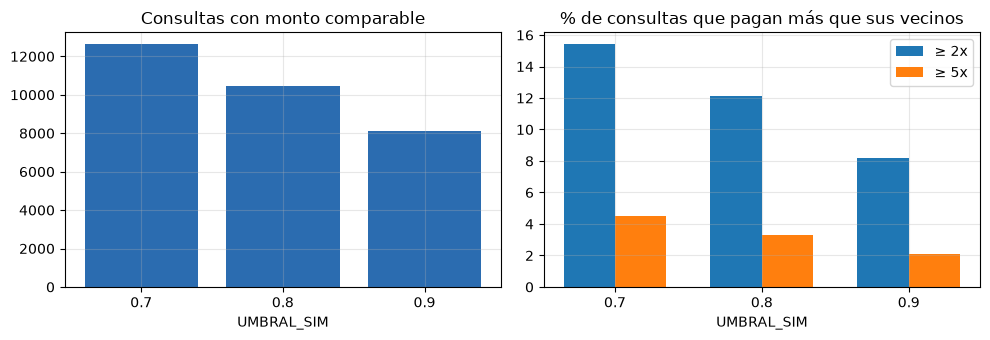

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
x = tabla_us["UMBRAL_SIM"].astype(str)
ax[0].bar(x, tabla_us["consultas_con_monto"], color="#2b6cb0"); ax[0].set_title("Consultas con monto comparable"); ax[0].set_xlabel("UMBRAL_SIM")
w = .35; i = np.arange(len(x))
ax[1].bar(i - w / 2, tabla_us["frac_paga_2x"] * 100, w, label="≥ 2x"); ax[1].bar(i + w / 2, tabla_us["frac_paga_5x"] * 100, w, label="≥ 5x")
ax[1].set_xticks(i); ax[1].set_xticklabels(x); ax[1].set_xlabel("UMBRAL_SIM"); ax[1].set_title("% de consultas que pagan más que sus vecinos"); ax[1].legend()
mostrar_fig("umbral_sim")

- Con 0.70 entran más pares (50,929) pero menos parecidos: el % que paga 2x o más sube a 15.4%

- Con 0.90 quedan 19,810 pares y el % baja a 8.2%: cuanto más parecido el texto, más parecido el monto

- La conclusión no cambia con el umbral: la mediana sigue en 1x y los casos de 2x o más son una minoría (8–15%)

### 10. Variación del resultado: `K` y `NPROBE`

- Se cambia **un parámetro a la vez** (el resto queda en su valor elegido) y se mide cómo cambia la respuesta a P3, no el recall de la técnica (eso está en `c_bus_ivf`)

- `K` = 5 / 10 / 20: cuántos vecinos se comparan con cada consulta

- `NPROBE` = 1 / 2 / 4: cuántas listas del IVF se revisan; con más listas entran vecinos que el índice perdía

- Todas las configuraciones, incluida la elegida, se calculan sobre la misma muestra de consultas para que sean comparables

In [21]:
N_VAR = 5_000              # consultas (25% de la muestra de c): cada búsqueda tarda ~1 min y los % se estiman con ±1 pp
spark.conf.set("spark.sql.optimizer.windowGroupLimitThreshold", "-1")   # top-K sin atajos de Spark 3.5.0, igual que en c

consultas = spark.read.parquet(str(ann_dir / "c_bus_ivf" / "consultas"))
cons_v = consultas.sample(fraction=min(1.0, N_VAR / consultas.count()), seed=SEED).drop("listas_probe").cache()
indice = (spark.read.parquet(str(vectores_dir)).join(spark.read.parquet(str(listas_dir)).select("ocid", "lista"), "ocid")
               .select("ocid", "categoria", "lista", "entidad", "region", "monto_final", "idx", "val").cache())
idx_v = indice.select(F.col("ocid").alias("ocid_v"), "lista", "categoria", F.col("idx").alias("idx_v"), F.col("val").alias("val_v"))
meta = indice.select("ocid", "entidad", "region", "monto_final")
centroides_bc = sc.broadcast(np.array([r_["centroide"] for r_ in spark.read.parquet(str(centroides_dir)).orderBy("lista").collect()]))

def vecinos_con(k, nprobe):
    # misma búsqueda IVF de c_bus_ivf con otro K o NPROBE
    q = (cons_v.withColumn("listas_probe", asignar_listas_udf(centroides_bc, nprobe)("idx", "val"))
               .select(F.col("ocid").alias("ocid_q"), "categoria", F.explode("listas_probe").alias("lista"),
                       F.col("idx").alias("idx_q"), F.col("val").alias("val_q")))
    cand = (idx_v.join(F.broadcast(q), ["lista", "categoria"]).where("ocid_q != ocid_v")
                 .select("ocid_q", "ocid_v", coseno("idx_q", "val_q", "idx_v", "val_v").alias("cos_sim")))
    mq = meta.select(*[F.col(c).alias(f"{c}_q") for c in meta.columns])
    mv = meta.select(*[F.col(c).alias(f"{c}_v") for c in meta.columns])
    return (top_k(cand, k=k).join(mq, "ocid_q").join(mv, "ocid_v")
                .withColumn("misma_entidad", F.col("entidad_q") == F.col("entidad_v"))
                .withColumn("misma_region", F.col("region_q") == F.col("region_v")).cache())

def resultado(v):
    m = v.where(F.col("cos_sim") >= UMBRAL_SIM)
    con = m.where((F.col("monto_final_q") > 0) & (F.col("monto_final_v") > 0))
    r_ = (con.groupBy("ocid_q", "monto_final_q").agg(F.expr("percentile_approx(monto_final_v, 0.5)").alias("mediana_v"))
             .withColumn("ratio", F.col("monto_final_q") / F.col("mediana_v"))
             .agg(F.count("*").alias("consultas"), F.avg((F.col("ratio") >= 2).cast("int")).alias("f2"),
                  F.avg((F.col("ratio") >= 5).cast("int")).alias("f5")).first())
    dif = {row["misma_entidad"]: row["d"] for row in
           con.groupBy("misma_entidad").agg(F.expr("percentile_approx(abs(log2(monto_final_q / monto_final_v)), 0.5)").alias("d")).collect()}
    return {"vecinos": v.count(), "pct_muy_parecidos": round(100 * m.count() / v.count(), 1), "consultas_con_monto": r_["consultas"],
            "pct_paga_2x": round(100 * r_["f2"], 1), "pct_paga_5x": round(100 * r_["f5"], 1),
            "ratio_misma_entidad": round(2 ** dif.get(True, 0), 2), "ratio_otra_entidad": round(2 ** dif.get(False, 0), 2)}

t0 = time.time()
v20 = vecinos_con(20, NPROBE)
filas = [{"parametro": "K", "valor": k_, **resultado(v20.where(F.col("rank") <= k_))} for k_ in [5, K, 20]]
for p_ in [1, 4]:
    v_ = vecinos_con(K, p_)
    filas.append({"parametro": "NPROBE", "valor": p_, **resultado(v_)}); v_.unpersist()
variacion_p3 = pd.DataFrame(filas)
variacion_p3.insert(0, "elegido", (variacion_p3["parametro"] == "K") & (variacion_p3["valor"] == K))
print(f"{cons_v.count():,} consultas | {time.time() - t0:,.0f} s")
variacion_p3

5,085 consultas | 240 s


,elegido,parametro,valor,vecinos,pct_muy_parecidos,consultas_con_monto,pct_paga_2x,pct_paga_5x,ratio_misma_entidad,ratio_otra_entidad
0,False,K,5,25425,25.8,2622,11.4,3.0,1.26,2.05
1,True,K,10,50850,15.8,2622,11.5,3.1,1.33,2.08
2,False,K,20,101700,9.6,2622,11.7,3.1,1.36,2.11
3,False,NPROBE,1,50794,15.1,2546,11.2,2.9,1.31,2.09
4,False,NPROBE,4,50850,16.0,2642,11.7,3.1,1.33,2.08


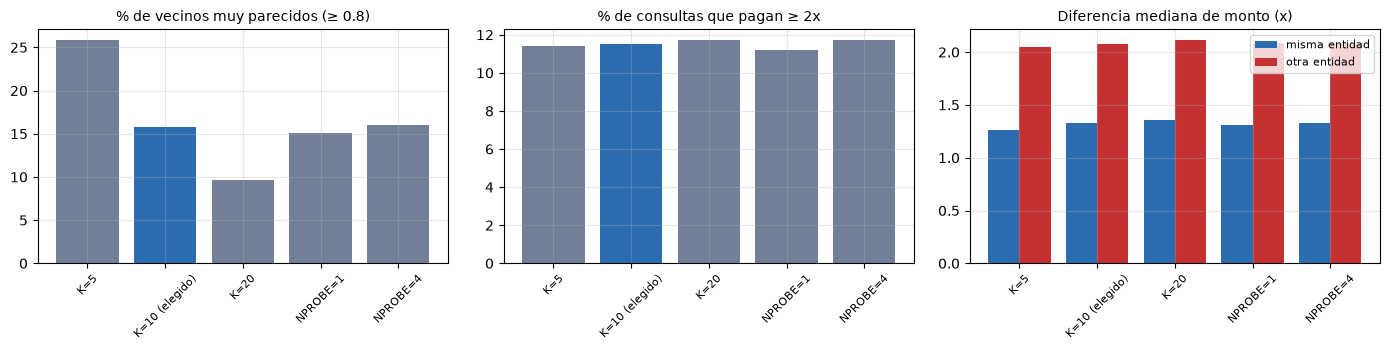

In [22]:
etiquetas = [f"{p}={v}" + (" (elegido)" if e else "") for p, v, e in zip(variacion_p3["parametro"], variacion_p3["valor"], variacion_p3["elegido"])]
colores = ["#2b6cb0" if e else "#718096" for e in variacion_p3["elegido"]]
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
ax[0].bar(etiquetas, variacion_p3["pct_muy_parecidos"], color=colores); ax[0].set_title(f"% de vecinos muy parecidos (≥ {UMBRAL_SIM})", fontsize=10)
ax[1].bar(etiquetas, variacion_p3["pct_paga_2x"], color=colores); ax[1].set_title("% de consultas que pagan ≥ 2x", fontsize=10)
x = np.arange(len(etiquetas))
ax[2].bar(x - .2, variacion_p3["ratio_misma_entidad"], .4, color="#2b6cb0", label="misma entidad")
ax[2].bar(x + .2, variacion_p3["ratio_otra_entidad"], .4, color="#c53030", label="otra entidad")
ax[2].set_xticks(x); ax[2].set_xticklabels(etiquetas); ax[2].set_title("Diferencia mediana de monto (x)", fontsize=10); ax[2].legend(fontsize=8)
for a_ in ax: a_.tick_params(axis="x", rotation=45, labelsize=8)
mostrar_fig("variacion_p3")

- **`K`:** con más vecinos baja el % de vecinos muy parecidos (25.8% con 5, 15.8% con 10, 9.6% con 20), porque los que se agregan son menos parecidos; pero el % que paga 2x o más casi no cambia (11.4%–11.7%)

- Las consultas con un vecino muy parecido son las mismas con cualquier `K` (2,622): si tienen uno, ya aparece entre los 5 primeros

- **`NPROBE`:** revisar 1 o 4 listas cambia muy poco (11.2% y 11.7% pagan 2x o más): los vecinos muy parecidos están casi siempre en la lista de la propia consulta

- **La diferencia por entidad se mantiene en todas:** ~1.3x dentro de la misma entidad y ~2.1x con otra

- Conclusión: la respuesta a P3 no depende de `K` ni de `NPROBE`

### 11. Técnicas: IVF propio vs faiss (IVF y HNSW)

In [23]:
def leer(nb_, tabla):
    ruta = ann_dir / nb_ / "tablas" / tabla
    assert ruta.exists(), f"Corre {nb_}.ipynb (Run All) antes que este notebook."
    return spark.read.parquet(str(ruta)).toPandas()

res_c, comp_d = leer("c_bus_ivf", "resumen").iloc[0], leer("d_faiss", "comparacion")
def mejor(m):
    # configuración más rápida con recall@K ≥ 0.9 (o la de mayor recall si ninguna llega)
    d_ = comp_d[comp_d.metodo == m]; ok = d_[d_.recall_at_k >= 0.9]
    return (ok.sort_values("ms_por_consulta") if len(ok) else d_.sort_values("recall_at_k", ascending=False)).head(1)

tecnicas = pd.concat([
    pd.DataFrame([{"metodo": "IVF propio (Spark)", "config": f"nlist={int(res_c['NLIST'])}, nprobe={int(res_c['NPROBE'])}",
                   "datos": f"{int(res_c['consultas']):,} consultas sobre 236k vectores", "recall_at_k": res_c["recall_at_k"],
                   "aceleracion_vs_exacto": round(res_c["seg_fuerza_bruta"] / res_c["seg_ivf"], 1)}]),
    *[mejor(m).assign(metodo=f"{m} (faiss)", datos="1,000 consultas sobre 20k vectores")[["metodo", "config", "datos", "recall_at_k", "aceleracion_vs_exacto"]]
      for m in ["IVF", "HNSW"]]], ignore_index=True)
tecnicas

,metodo,config,datos,recall_at_k,aceleracion_vs_exacto
0,IVF propio (Spark),"nlist=300, nprobe=2","20,062 consultas sobre 236k vectores",0.7500,14.7
1,IVF (faiss),nprobe=32,"1,000 consultas sobre 20k vectores",0.8923,3.8
2,HNSW (faiss),efSearch=16,"1,000 consultas sobre 20k vectores",0.9799,20.9


- **IVF propio (Spark):** recall 75% y 14.7x más rápido que la fuerza bruta sobre los 236k procesos; es el único que escala distribuido

- **IVF (faiss):** necesita revisar el 23% del índice para llegar a 89% de recall (3.8x más rápido)

- **HNSW (faiss):** 98% de recall con respuesta 21x más rápida; es la mejor opción si el índice cabe en una máquina

- Para P3 basta el IVF de Spark: se buscan vecinos con coseno ≥ 0.80, que son los más fáciles de encontrar; un recall mayor agregaría pocos pares de ese nivel

### 12. Respuesta a P3

- **¿Cuánto varía el monto entre compras de objeto parecido?** Poco en la mayoría: la mediana paga lo mismo que sus vecinos y la mitad central está entre 0.90x y 1.25x

- **Pero hay una cola real:** el 12% paga el doble o más que sus vecinos y el 3%, cinco veces o más

- **La variación no es regional:** ninguna región paga sistemáticamente más (máximo ≈ 1.13x); la diferencia aparece al comparar **entidades distintas**, que compran escalas distintas del mismo objeto

- **Indicio de sobreprecio:** la lista de consultas que pagan 2x o 5x sobre sus vecinos es el punto de partida para revisar, siempre comparando con la cantidad comprada

### 13. Limitaciones

- **Una diferencia de monto no es sobreprecio:** el monto es total, no unitario; haría falta la cantidad o el precio por ítem para fijar precios de referencia

- El recall de 75% del IVF de Spark implica que algunos vecinos verdaderos no aparecen, y se analizan 20 mil consultas, no los 236 mil procesos; aun así, con `K` 5–20 y `NPROBE` 1–4 el resultado casi no cambia (sección 10)

- El umbral de "muy parecido" (coseno ≥ 0.80) y el mínimo de 20 consultas por región o entidad son decisiones del equipo; la sección 9 muestra que la conclusión se mantiene entre 0.70 y 0.90

- Los montos en otras monedas están convertidos a soles con el tipo de cambio mensual del BCRP, así que son comparables con el resto

---
### 14. Síntesis

- **Respuesta a P3:** entre compras de objeto parecido el monto varía poco en la mayoría (0.90x–1.25x), con una cola del 12% que paga el doble o más

- **La diferencia es de entidad, no de región:** comparar con otra entidad duplica la diferencia, porque el mismo texto describe compras de escala distinta

- **Técnica:** TF-IDF de palabras + IVF propio en Spark escala a los 236k procesos con recall de 75%; en faiss, HNSW llega a 98% de recall respondiendo 21x más rápido que la fuerza bruta

- **Siguiente paso** para precios de referencia: incorporar cantidad o precio unitario por ítem; con eso los vecinos de ANN serían una referencia directa

### 15. Escritura de resultados

Tablas en `temp/e_analisis/tablas` (parquet) y `web/` (json)

In [24]:
tablas = {"variacion_monto": var.select("ocid_q", "region_q", "categoria", "monto_final_q", "monto_mediana_vecinos", "ratio").toPandas(),
          "otra_region": cruce, "regiones": reg_var.toPandas(), "entidades": ent_var.toPandas(), "umbral_sim": tabla_us, "variacion_p3": variacion_p3, "tecnicas": tecnicas}
escritos = {nombre: guardar_tabla(df, nombre) for nombre, df in tablas.items()}
print(f"Escrito en temp/e_analisis/: {', '.join(escritos)}")

Escrito en temp/e_analisis/: variacion_monto, otra_region, regiones, entidades, umbral_sim, variacion_p3, tecnicas


#### a. Verificación

In [25]:
for nombre, n in escritos.items():
    leido = spark.read.parquet(str(tab_dir / nombre)).count()
    assert leido == n, f"{nombre}: esperaba {n}, leí {leido}"
    assert (web_dir / f"{nombre}.json").exists(), f"falta web/{nombre}.json"

figs = sorted(p.stem for p in fig_dir.glob("*.png"))
print(f"OK: {len(escritos)} tablas (parquet + json) | {len(figs)} figuras: {', '.join(figs)}")

OK: 7 tablas (parquet + json) | 7 figuras: misma_entidad, otra_region, region_mediana, regiones, umbral_sim, variacion_monto, variacion_p3


---
### 16. Cerrar sesión

In [26]:
spark.stop()